In [1]:
from spin_lattices import SquareLatticeNoDiag, ChainLattice, SpinLattice, ParallelogramSpinLattice
from spin_systems import heisenberg, SpinSystem, no_symmetries_basis
import lattice_symmetries as ls
from dataclasses import dataclass
import numpy.typing as npt
import numpy as np
from functools import reduce
import operator
import itertools
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh
import json
import jsonlines
from tqdm.auto import tqdm
from misc_utils import get_json_for_basis

In [2]:
lattice = SquareLatticeNoDiag(4, 4, enumerate_along='x')

In [3]:
# Data(
#     edge_index=[2, 45],
#     x_nodes=[10, 2],
#     x_edges=[45, 1],
#     y_node_rdms=[10, 2, 2],
#     y_edge_rdms=[45, 4, 4],
#     y_energy=-8.740063667297363,
#     grid_extent=[2],
#     pbc=False,
# )

$$H = -\left(\sum_{i=0}^{44} \mathtt{x\_edges[i, 0]} \sigma^z_{\mathtt{edge\_index[0, i]}} \sigma^z_{\mathtt{edge\_index[1, i]}} + \right.\\
\sum_{j=0}^{9} \mathtt{x\_nodes[j, 0]}\sigma^x_j + 
\left.\sum_{j=0}^{9} \mathtt{x\_nodes[j, 1]} \sigma^z_j\right)$$

In [4]:
@dataclass
class Data:
    edge_index: npt.NDArray[
        np.int64
    ]  # shape (2, n_edges), where n_edges = n_nodes * (n_nodes - 1) / 2
    x_nodes: npt.NDArray[np.float64]  # shape (n_nodes, 2)
    x_edges: npt.NDArray[np.float64]  # shape (n_edges, 1)
    pbc: bool  # periodic boundary conditions

    y_node_rdms: npt.NDArray[np.float64] | None = None  # shape (n_nodes, 2, 2)
    y_edge_rdms: npt.NDArray[np.float64] | None = None  # shape (n_edges, 4, 4)
    y_energy: float | None = None
    grid_extent: tuple[int, int] | None = None
    real_edge_index: npt.NDArray[np.int64] | None = None  # shape (2, n_real_edges)

    def to_hamiltonian_expression(self):
        assert self.x_edges.shape[1] == 1
        return (
            reduce(
                operator.add,
                (
                    coeff * ls.Expr("σᶻ₀ σᶻ₁", sites=[[int(i), int(j)]])
                    for coeff, (i, j) in zip(self.x_edges[:, 0], self.edge_index.T)
                ),
            )
            + reduce(
                operator.add,
                (
                    coeff * ls.Expr("σˣ₀", sites=[[int(i)]])
                    for i, coeff in enumerate(self.x_nodes[:, 0])
                ),
            )
            + reduce(
                operator.add,
                (
                    coeff * ls.Expr("σᶻ₀", sites=[[int(i)]])
                    for i, coeff in enumerate(self.x_nodes[:, 1])
                ),
            )
        )
    
class DataEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, Data):
            return obj.__dict__  # Convert Data object to a dictionary
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

In [5]:
[
    tuple(sorted(edge)) for edge in (itertools.combinations(range(lattice.number_spins), 2))
] == list(itertools.combinations(range(lattice.number_spins), 2))

True

In [6]:
def random_sample_coeffs(lattice: SquareLatticeNoDiag) -> Data:
    all_edges = np.array(
        [
            sorted(edge)
            for edge in (itertools.combinations(range(lattice.number_spins), 2))
        ]
    ).T
    edge_to_idx = {tuple((edge)): idx for idx, edge in enumerate(all_edges.T)}
    real_edges_idxs = np.array(
        [
            edge_to_idx[tuple(sorted(edge))]
            for edge, kind in lattice.edges_to_kind.items()
        ]
    )
    x_nodes = np.random.uniform(-1, 1, size=(lattice.number_spins, 2))
    x_edges = np.zeros((all_edges.shape[1], 1))
    x_edges[real_edges_idxs, 0] = np.random.uniform(-1, 1, size=(len(real_edges_idxs)))
    return Data(
        edge_index=all_edges,
        x_nodes=x_nodes,
        x_edges=x_edges,
        pbc=False,
        grid_extent=(lattice.width + 1, lattice.height + 1),
    )


def rdms1(
    ground_state: npt.NDArray[np.float64], n_spins: int
) -> npt.NDArray[np.float64]:
    ground_state_reshaped = ground_state.reshape((2,) * n_spins).transpose(
        range(n_spins - 1, -1, -1)
    )
    rdms = []
    for spin in range(n_spins):
        ground_state_transposed = ground_state_reshaped.transpose(
            tuple((spin,) + tuple(range(spin)) + tuple(range(spin + 1, n_spins)))
        ).reshape((2, 2 ** (n_spins - 1)))
        rdms.append(
            np.einsum("ia,ja->ij", ground_state_transposed, ground_state_transposed)
        )
    return np.array(rdms)


def rdms2(
    ground_state: npt.NDArray[np.float64], n_spins: int
) -> npt.NDArray[np.float64]:
    ground_state_reshaped = ground_state.reshape((2,) * n_spins).transpose(
        range(n_spins - 1, -1, -1)
    )
    rdms = []
    for spin1, spin2 in itertools.combinations(range(n_spins), 2):
        idxs = tuple(sorted(set(range(n_spins)) - {spin1, spin2}))
        ground_state_transposed = ground_state_reshaped.transpose(
            tuple((spin1, spin2) + idxs)
        ).reshape((4, 2 ** (n_spins - 2)))
        rdms.append(
            np.einsum("ia,ja->ij", ground_state_transposed, ground_state_transposed)
        )
    return np.array(rdms)

<Axes: xlabel='emb_x', ylabel='emb_y'>

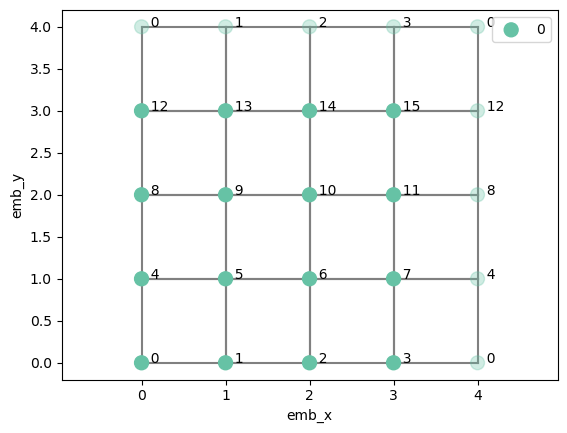

In [52]:
lattice.plot()

In [7]:
from spin_systems import spin_system


lattice = SquareLatticeNoDiag(4, 4, enumerate_along='x')
system = spin_system(heisenberg(lattice), no_symmetries_basis(hamming_weight=None))
all_rdms = rdms2(system.ground_state, lattice.number_spins)

2024-07-03 23:17:14.250 | DEBUG    | spin_systems:_find_cached_eigenstate:189 - Using cached version of eigenvalues / eigenstates up to 1.


In [9]:
expr = system.hamiltonian.expression.to_json()
basis_json = system.basis.

AttributeError: 'Basis' object has no attribute 'to_json'

In [89]:
list(itertools.combinations(range(lattice.number_spins), 2))[15]

(1, 2)

In [92]:
np.allclose(all_rdms[0], all_rdms[15])

True

In [66]:
ground_state_reshaped = ground_state.reshape((2,) * lattice.number_spins)

In [67]:
np.allclose(ground_state_reshaped, ground_state_reshaped.transpose()

array([[[[[[[[[[[[[[[[-1.01819048e-17, -5.35324259e-19],
                     [-3.55146299e-18, -4.21807653e-19]],

                    [[-4.86465585e-18, -9.21674160e-20],
                     [-1.27894868e-18, -1.00854608e-18]]],


                   [[[ 6.15764440e-18, -1.02521947e-18],
                     [-6.26425877e-19,  6.61090083e-19]],

                    [[-1.35765545e-18,  2.70922882e-19],
                     [-3.09420317e-19,  3.34677814e-19]]]],



                  [[[[-7.67206118e-18, -2.47975377e-18],
                     [-2.41256832e-18,  9.51369168e-19]],

                    [[-2.04511928e-18, -1.76993394e-18],
                     [ 2.35892750e-18, -1.45683659e-18]]],


                   [[[-3.74131953e-19,  1.42130188e-18],
                     [ 2.45505676e-18,  1.42925711e-18]],

                    [[ 2.86453176e-18,  1.06585010e-18],
                     [ 1.75947899e-18, -5.48383066e-19]]]]],




                 [[[[[-3.16751244e-18, -1.44125225e-18],
 

In [63]:
all_rdms[4]

array([[ 3.21255095e-01,  2.42879657e-15,  2.41695270e-15,
        -2.56860385e-16],
       [ 2.42879657e-15,  1.78744905e-01,  1.42510190e-01,
         2.26517495e-15],
       [ 2.41695270e-15,  1.42510190e-01,  1.78744905e-01,
         2.24563289e-15],
       [-2.56860385e-16,  2.26517495e-15,  2.24563289e-15,
         3.21255095e-01]])

In [58]:
all_rdms[4]

array([[ 3.21255095e-01,  2.39363279e-15,  2.41421610e-15,
        -2.55669673e-16],
       [ 2.39363279e-15,  1.78744905e-01,  1.42510190e-01,
         2.26791155e-15],
       [ 2.41421610e-15,  1.42510190e-01,  1.78744905e-01,
         2.23578368e-15],
       [-2.55669673e-16,  2.26791155e-15,  2.23578368e-15,
         3.21255095e-01]])

In [145]:
lattice = SquareLatticeNoDiag(3, 3, enumerate_along="x", boundary_conditions="open")
for _ in tqdm(range(100)):
    data = random_sample_coeffs(lattice)
    system = SpinSystem(
        lattice=lattice,
        hamiltonian=ls.Operator(
            expression=data.to_hamiltonian_expression(),
            basis=ls.SpinBasis(number_spins=lattice.number_spins),
        ),
    )
    system.get_eigenstates(1)
    data.y_node_rdms = rdms1(system.ground_state, lattice.number_spins)
    data.y_edge_rdms = rdms2(system.ground_state, lattice.number_spins)
    data.y_energy = system.ground_energy
    with jsonlines.open(
        "data.jsonl", mode="a", dumps=lambda x: json.dumps(x, cls=DataEncoder)
    ) as writer:
        writer.write(data)

  0%|          | 0/100 [00:00<?, ?it/s]

2024-07-01 20:36:00.511 | DEBUG    | spin_systems:get_eigenstates:224 - Calculating eigenvalues / eigenstates
2024-07-01 20:36:05.598 | DEBUG    | spin_systems:get_eigenstates:235 - Ground state energy is -15.2657652078
2024-07-01 20:36:05.736 | DEBUG    | spin_systems:get_eigenstates:224 - Calculating eigenvalues / eigenstates
2024-07-01 20:36:12.849 | DEBUG    | spin_systems:get_eigenstates:235 - Ground state energy is -15.8216108103
2024-07-01 20:36:12.985 | DEBUG    | spin_systems:get_eigenstates:224 - Calculating eigenvalues / eigenstates
2024-07-01 20:36:17.505 | DEBUG    | spin_systems:get_eigenstates:235 - Ground state energy is -17.4667829090
2024-07-01 20:36:17.639 | DEBUG    | spin_systems:get_eigenstates:224 - Calculating eigenvalues / eigenstates
2024-07-01 20:36:22.835 | DEBUG    | spin_systems:get_eigenstates:235 - Ground state energy is -14.4979432120
2024-07-01 20:36:22.965 | DEBUG    | spin_systems:get_eigenstates:224 - Calculating eigenvalues / eigenstates
2024-07-01